# Zomato Delivery Operations Analysis
**Nama:** Fatwa Ferdiansyah

**Problem Statement:** Selama periode 11 Februari sampai 6 April 2022, 29,9% dari 45.493 pesanan Zomato tiba lebih dari 30 menit setelah dipesan. Pada jam makan malam (19.00 sampai 22.00), angkanya naik menjadi 50%, sehingga satu dari dua pelanggan menerima makanan terlambat tepat di jam permintaan tertinggi. Keterlambatan menurunkan pengalaman pelanggan dan rating kurir, tetapi Zomato belum mengetahui faktor operasional mana yang paling berkontribusi terhadap keterlambatan dan mana yang dapat dikendalikan perusahaan.

**Business Questions:**
1. Berapa tingkat keterlambatan (late rate) secara keseluruhan, dan bagaimana polanya per hari dan per jam?
2. Faktor apa yang menghasilkan perbedaan late rate paling besar?
3. Dari faktor tersebut, mana yang dapat dikendalikan perusahaan dan mana yang hanya bisa diantisipasi?
4. Kombinasi kondisi apa yang paling berisiko menghasilkan keterlambatan?

#### Import library

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Data Understanding

#### Load data

In [39]:
df_raw = pd.read_csv("Zomato Dataset.csv")
df = df_raw.copy()
print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


#### Struktur data

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

#### Cek missing values

In [41]:
missing = df.isna().sum().to_frame("jumlah_missing")
missing["persen"] = (missing["jumlah_missing"] / len(df) * 100).round(2)
missing[missing["jumlah_missing"] > 0].sort_values("jumlah_missing", ascending=False)

,jumlah_missing,persen
Delivery_person_Ratings,1908,4.19
Delivery_person_Age,1854,4.07
Time_Orderd,1731,3.80
City,1200,2.63
multiple_deliveries,993,2.18
Weather_conditions,616,1.35
Road_traffic_density,601,1.32
Festival,228,0.50


Ada 8 kolom yang punya data kosong, tapi jumlahnya kecil, semuanya di bawah 5%. Yang paling banyak kosong adalah rating kurir (4,19%), disusul umur kurir (4,07%). Karena jumlahnya sedikit, data yang kosong akan diisi, bukan dibuang, supaya jumlah baris tetap utuh.

#### Cek duplikat

In [42]:
print("Baris duplikat penuh:", df.duplicated().sum())
print("ID order duplikat   :", df["ID"].duplicated().sum())

Baris duplikat penuh: 0
ID order duplikat   : 0


#### Cek nilai unik kolom kategorikal

In [43]:
kolom_kategori = ["Weather_conditions", "Road_traffic_density", "Type_of_order",
                  "Type_of_vehicle", "Festival", "City", "Vehicle_condition", "multiple_deliveries"]
for c in kolom_kategori:
    print(c, "->", df[c].value_counts(dropna=False).to_dict())

Weather_conditions -> {'Fog': 7653, 'Stormy': 7584, 'Cloudy': 7533, 'Sandstorms': 7494, 'Windy': 7422, 'Sunny': 7282, nan: 616}
Road_traffic_density -> {'Low': 15476, 'Jam': 14139, 'Medium': 10945, 'High': 4423, nan: 601}
Type_of_order -> {'Snack': 11530, 'Meal': 11456, 'Drinks': 11321, 'Buffet': 11277}
Type_of_vehicle -> {'motorcycle': 26429, 'scooter': 15273, 'electric_scooter': 3814, 'bicycle': 68}
Festival -> {'No': 44460, 'Yes': 896, nan: 228}
City -> {'Metropolitian': 34087, 'Urban': 10133, nan: 1200, 'Semi-Urban': 164}
Vehicle_condition -> {2: 15031, 1: 15028, 0: 15005, 3: 520}
multiple_deliveries -> {1.0: 28151, 0.0: 14094, 2.0: 1985, nan: 993, 3.0: 361}


#### Statistik deskriptif kolom numerik

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
Delivery_person_Ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
Restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
Restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken (min),45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


Nilai yang tidak masuk akal adalah umur kurir 15 tahun (di bawah umur kerja), rating kurir 6 (padahal skala maksimalnya 5), dan koordinat restoran yang bernilai 0 atau negatif (tidak mungkin, karena seluruh restoran berada di India yang koordinatnya positif). Nilai-nilai ini perlu dibersihkan sebelum analisis.



## 2. Data Preprocessing

#### Rename kolom target

In [45]:
df = df.rename(columns={"Time_taken (min)": "delivery_time_min"})

#### Ubah Order_Date menjadi tipe tanggal

In [46]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y")
print("Periode data:", df["Order_Date"].min().date(), "sampai", df["Order_Date"].max().date())

Periode data: 2022-02-11 sampai 2022-04-06


#### Fungsi untuk merapikan format jam

In [47]:
# Kolom jam punya 3 format campuran: "21:55", "24:05:00", dan pecahan Excel "0.8333".
def jam_ke_menit(series):
    s = series.astype(str).str.strip()
    hasil = pd.Series(np.nan, index=s.index)
    pola_jam = s.str.match(r"^\d{1,2}:\d{2}(:\d{2})?$")
    bagian = s[pola_jam].str.split(":", expand=True)
    hasil[pola_jam] = bagian[0].astype(int) * 60 + bagian[1].astype(int)
    pecahan = pd.to_numeric(s[~pola_jam], errors="coerce")
    hasil[~pola_jam] = (pecahan * 1440).round()
    return hasil % 1440

df["order_minute"] = jam_ke_menit(df["Time_Orderd"])
df["pickup_minute"] = jam_ke_menit(df["Time_Order_picked"])

#### Hitung jam order dan waktu tunggu pickup

In [48]:
df["order_hour"] = (df["order_minute"] // 60)
df["pickup_wait_min"] = (df["pickup_minute"] - df["order_minute"]) % 1440
print(df["pickup_wait_min"].value_counts(dropna=False))

pickup_wait_min
5.0     14701
15.0    14606
10.0    14546
NaN      1731
Name: count, dtype: int64


Waktu tunggu pickup hanya muncul di angka 5, 10, atau 15 menit saja. Ini artinya data ini tidak dicatat secara presisi, kemungkinan dibulatkan atau memang sistemnya hanya menyediakan pilihan tersebut. Jadi kolom ini kurang bisa diandalkan untuk analisis detail.

#### Audit anomali data (data integrity check)

In [49]:
anomali = pd.DataFrame({
    "Umur kurir 15 tahun (di bawah umur)": [(df["Delivery_person_Age"] < 18).sum()],
    "Rating kurir di atas 5 (skala maks 5)": [(df["Delivery_person_Ratings"] > 5).sum()],
    "Koordinat restoran bernilai 0": [((df["Restaurant_latitude"] == 0) | (df["Restaurant_longitude"] == 0)).sum()],
    "Koordinat restoran bernilai negatif": [((df["Restaurant_latitude"] < 0) | (df["Restaurant_longitude"] < 0)).sum()],
    "Jam order tersimpan sebagai pecahan Excel": [(~df["Time_Orderd"].astype(str).str.contains(":") & df["Time_Orderd"].notna()).sum()],
}).T.rename(columns={0: "jumlah_baris"})
anomali["persen"] = (anomali["jumlah_baris"] / len(df) * 100).round(2)
anomali

,jumlah_baris,persen
Umur kurir 15 tahun (di bawah umur),38,0.08
Rating kurir di atas 5 (skala maks 5),53,0.12
Koordinat restoran bernilai 0,3640,7.99
Koordinat restoran bernilai negatif,431,0.95
Jam order tersimpan sebagai pecahan Excel,4068,8.92


#### Cek pola anomali umur dan rating

In [50]:
print("Umur 15 dan rating 1:", ((df["Delivery_person_Age"] == 15) & (df["Delivery_person_Ratings"] == 1)).sum())
print("Rating 6 dan umur 50:", ((df["Delivery_person_Ratings"] == 6) & (df["Delivery_person_Age"] == 50)).sum())
print("ID kurir dengan lebih dari 1 umur:",
      (df.groupby("Delivery_person_ID")["Delivery_person_Age"].nunique() > 1).sum(),
      "dari", df["Delivery_person_ID"].nunique(), "ID")

Umur 15 dan rating 1: 38
Rating 6 dan umur 50: 53
ID kurir dengan lebih dari 1 umur: 1320 dari 1320 ID


Ada 38 baris dengan umur 15 yang semuanya punya rating 1, dan 53 baris dengan rating 6 yang semuanya berumur 50. Pola yang identik seperti ini menunjukkan data placeholder atau data uji, bukan kurir sungguhan, jadi 91 baris ini dibuang (0,2% data). Delivery_person_ID juga tidak bisa dipakai untuk analisis per kurir, karena 1.320 dari 1.320 ID tercatat dengan lebih dari satu umur, sehingga satu ID tidak mewakili satu orang.

#### Tandai lalu buang baris placeholder (umur 15 dan rating 6)

In [51]:
df["is_placeholder"] = (df["Delivery_person_Age"] < 18) | (df["Delivery_person_Ratings"] > 5)
print("Baris placeholder dibuang:", df["is_placeholder"].sum())
df = df[~df["is_placeholder"]].copy()

Baris placeholder dibuang: 91


#### Perbaiki koordinat

In [52]:
df["Restaurant_latitude"] = df["Restaurant_latitude"].abs()
df["Restaurant_longitude"] = df["Restaurant_longitude"].abs()
df["coord_valid"] = (df["Restaurant_latitude"] > 1) & (df["Restaurant_longitude"] > 1)
print("Baris dengan koordinat tidak valid:", (~df["coord_valid"]).sum())

Baris dengan koordinat tidak valid: 3630


#### Tangani missing values

In [53]:
for c in ["Weather_conditions", "Road_traffic_density", "Festival", "City"]:
    df[c] = df[c].fillna("Unknown")
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].median())
print(df.isna().sum()[df.isna().sum() > 0])

Time_Orderd        1640
order_minute       1640
order_hour         1640
pickup_wait_min    1640
dtype: int64


Untuk kolom kategori seperti cuaca dan lalu lintas, saya isi dengan "Unknown" karena kita tidak bisa menebak kondisi sebenarnya. Untuk kolom angka seperti umur dan rating, saya isi dengan nilai tengah (median), karena median tidak terpengaruh nilai ekstrem dan data yang kosong hanya sedikit (di bawah 5%), sehingga dampaknya terhadap hasil analisis minimal.

#### Cek outlier target dengan IQR

Q1: 19.0 Q3: 32.0 Batas atas IQR: 51.5
Jumlah outlier: 270


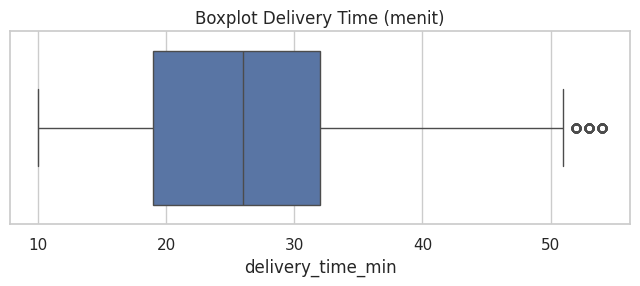

In [54]:
q1, q3 = df["delivery_time_min"].quantile([0.25, 0.75])
iqr = q3 - q1
batas_atas = q3 + 1.5 * iqr
print("Q1:", q1, "Q3:", q3, "Batas atas IQR:", batas_atas)
print("Jumlah outlier:", (df["delivery_time_min"] > batas_atas).sum())

fig, ax = plt.subplots(figsize=(8, 2.5))
sns.boxplot(x=df["delivery_time_min"], ax=ax, color="#4C72B0")
ax.set_title("Boxplot Delivery Time (menit)")
plt.show()

Outlier (data ekstrem) pada waktu pengiriman tetap dipertahankan karena keterlambatan ekstrem justru menjadi fokus analisis kita. Kalau dibuang, kita malah kehilangan informasi penting tentang pesanan yang paling bermasalah.

## 3. Feature Engineering

#### Feature engineering

In [55]:
SLA_MIN = 30
df["is_late"] = (df["delivery_time_min"] > SLA_MIN).astype(int)
df["delivery_status"] = np.where(df["is_late"] == 1, "Late (>30 min)", "On Time (<=30 min)")

def haversine(lat1, lon1, lat2, lon2):
    r = 6371
    p = np.pi / 180
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * r * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(df["Restaurant_latitude"], df["Restaurant_longitude"],
                              df["Delivery_location_latitude"], df["Delivery_location_longitude"]).round(2)
df.loc[~df["coord_valid"], "distance_km"] = np.nan
df["distance_group"] = pd.cut(df["distance_km"], [0, 5, 10, 15, 25],
                              labels=["0-5 km", "5-10 km", "10-15 km", "15+ km"])

def slot(h):
    if pd.isna(h): return "Unknown"
    if 6 <= h < 11: return "1 Morning (06-11)"
    if 11 <= h < 15: return "2 Lunch (11-15)"
    if 15 <= h < 17: return "3 Afternoon (15-17)"
    if 17 <= h < 19: return "4 Early Evening (17-19)"
    if 19 <= h < 22: return "5 Dinner Peak (19-22)"
    return "6 Late Night (22-06)"
df["time_slot"] = df["order_hour"].apply(slot)

df["day_name"] = df["Order_Date"].dt.day_name()
df["age_group"] = pd.cut(df["Delivery_person_Age"], [17, 25, 30, 35, 40],
                         labels=["20-25", "26-30", "31-35", "36-40"])
df["rating_group"] = pd.cut(df["Delivery_person_Ratings"], [0, 4.0, 4.5, 4.8, 5.0],
                            labels=["<=4.0", "4.1-4.5", "4.6-4.8", "4.9-5.0"])
df["batch_size"] = df["multiple_deliveries"].astype(int).map(
    {0: "0 (single)", 1: "1 extra", 2: "2 extra", 3: "3 extra"})
df["vehicle_condition_label"] = df["Vehicle_condition"].map(
    {0: "0 (Poor)", 1: "1", 2: "2", 3: "3 (Best)"})
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,delivery_time_min,order_minute,pickup_minute,order_hour,pickup_wait_min,is_placeholder,coord_valid,is_late,delivery_status,distance_km,distance_group,time_slot,day_name,age_group,rating_group,batch_size,vehicle_condition_label
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,1315.0,1330.0,21.0,15.0,False,True,1,Late (>30 min),10.28,10-15 km,5 Dinner Peak (19-22),Saturday,36-40,4.1-4.5,3 extra,2
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,895.0,905.0,14.0,10.0,False,True,0,On Time (<=30 min),6.24,5-10 km,2 Lunch (11-15),Sunday,20-25,4.6-4.8,1 extra,1
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,1050.0,1060.0,17.0,10.0,False,True,0,On Time (<=30 min),13.79,10-15 km,4 Early Evening (17-19),Friday,20-25,4.6-4.8,1 extra,1
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,560.0,570.0,9.0,10.0,False,True,0,On Time (<=30 min),2.93,0-5 km,1 Morning (06-11),Sunday,31-35,4.1-4.5,0 (single),0 (Poor)
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,1190.0,1205.0,19.0,15.0,False,True,1,Late (>30 min),19.40,15+ km,5 Dinner Peak (19-22),Monday,20-25,4.6-4.8,1 extra,1


## 4. Exploratory Data Analysis (EDA)

#### Statistik deskriptif setelah cleaning

In [56]:
print("Baris akhir:", len(df))
print("Late rate (>30 menit):", round(df["is_late"].mean() * 100, 1), "%")
df[["delivery_time_min", "distance_km", "Delivery_person_Age", "Delivery_person_Ratings"]].describe().T

Baris akhir: 45493
Late rate (>30 menit): 29.9 %


,count,mean,std,min,25%,50%,75%,max
delivery_time_min,45493.0,26.296947,9.386912,10.00,19.00,26.00,32.00,54.00
distance_km,41863.0,9.718969,5.602425,1.47,4.66,9.19,13.68,20.97
Delivery_person_Age,45493.0,29.572923,5.643442,20.00,25.00,30.00,34.00,39.00
Delivery_person_Ratings,45493.0,4.637995,0.307473,2.50,4.60,4.70,4.80,5.00


#### Distribusi target

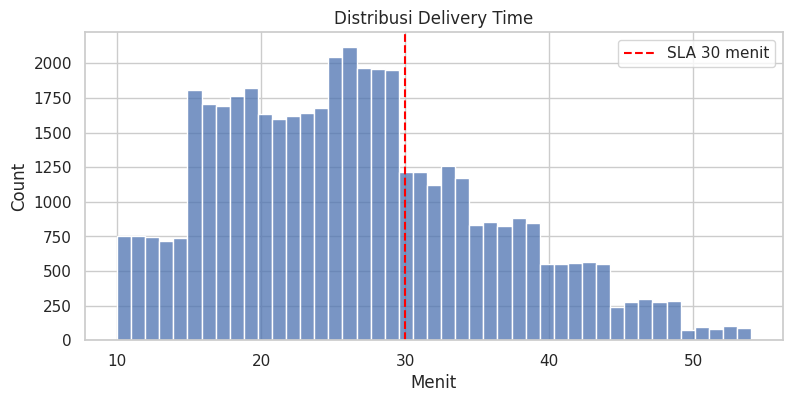

In [57]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["delivery_time_min"], bins=45, ax=ax, color="#4C72B0")
ax.axvline(SLA_MIN, color="red", linestyle="--", label="SLA 30 menit")
ax.set_title("Distribusi Delivery Time")
ax.set_xlabel("Menit")
ax.legend()
plt.show()

Rata-rata waktu pengiriman adalah 26,3 menit dan nilai tengahnya 26 menit. Sekitar 29,9% pesanan datang lebih dari 30 menit, artinya hampir 1 dari 3 pesanan terlambat.

#### Fungsi bantu untuk late rate per faktor

In [58]:
def late_rate(kolom, data=None):
    data = df if data is None else data
    t = (data.groupby(kolom, observed=True)
             .agg(orders=("ID", "count"),
                  avg_time=("delivery_time_min", "mean"),
                  late_rate=("is_late", "mean"))
             .round(3))
    t["late_rate_%"] = (t["late_rate"] * 100).round(1)
    return t.drop(columns="late_rate")

def plot_late(kolom, judul, data=None, urut=False):
    t = late_rate(kolom, data)
    if urut:
        t = t.sort_values("late_rate_%", ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=t.index.astype(str), y=t["late_rate_%"], ax=ax, color="#DD8452")
    ax.axhline(df["is_late"].mean() * 100, color="gray", linestyle="--", label="Rata-rata")
    ax.set_title(judul)
    ax.set_ylabel("Late rate (%)")
    ax.set_xlabel("")
    for i, v in enumerate(t["late_rate_%"]):
        ax.text(i, v + 1, f"{v}%", ha="center")
    ax.legend()
    plt.xticks(rotation=20)
    plt.show()
    return t

#### Late rate per kondisi traffic

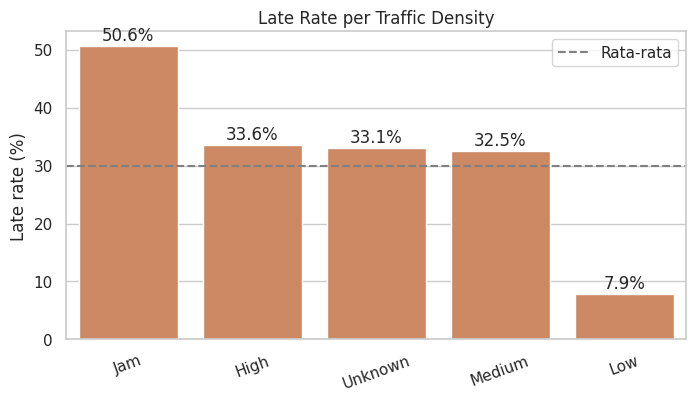

,orders,avg_time,late_rate_%
Road_traffic_density,,,
Jam,14139,31.176,50.6
High,4423,27.240,33.6
Unknown,510,26.853,33.1
Medium,10945,26.700,32.5
Low,15476,21.267,7.9


In [59]:
plot_late("Road_traffic_density", "Late Rate per Traffic Density", urut=True)

Saat lalu lintas macet total (Jam), tingkat keterlambatan mencapai 50,6%, jauh di atas rata-rata. Sebaliknya, saat lalu lintas lancar (Low), keterlambatan hanya 7,9%. Jadi kepadatan lalu lintas sangat berpengaruh terhadap keterlambatan.

Catatan: di data ini, kondisi Jam hanya muncul pada jam makan malam, jadi efek lalu lintas dan efek jam tidak bisa dipisahkan.

#### Late rate per cuaca

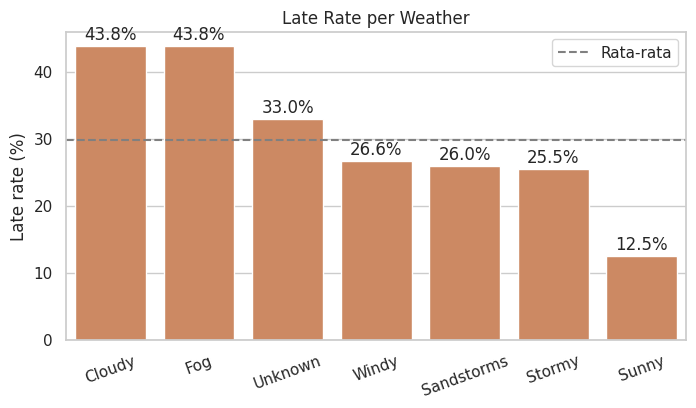

,orders,avg_time,late_rate_%
Weather_conditions,,,
Cloudy,7533,28.917,43.8
Fog,7653,28.915,43.8
Unknown,525,26.848,33.0
Windy,7422,26.119,26.6
Sandstorms,7494,25.876,26.0
Stormy,7584,25.869,25.5
Sunny,7282,21.857,12.5


In [60]:
plot_late("Weather_conditions", "Late Rate per Weather", urut=True)

Cuaca mendung (Cloudy) dan berkabut (Fog) memiliki late rate tertinggi (43,8%), dan cuaca cerah terendah (12,5%). Badai (Stormy) dan badai pasir (Sandstorms) justru lebih rendah (sekitar 26%) dibanding mendung. Jadi penjelasannya bukan sekadar "cuaca buruk", kemungkinan berkaitan dengan jarak pandang. Dampak cuaca juga jauh lebih besar saat jalan macet (lihat risk matrix).

#### Late rate per jumlah pesanan tambahan (batching)

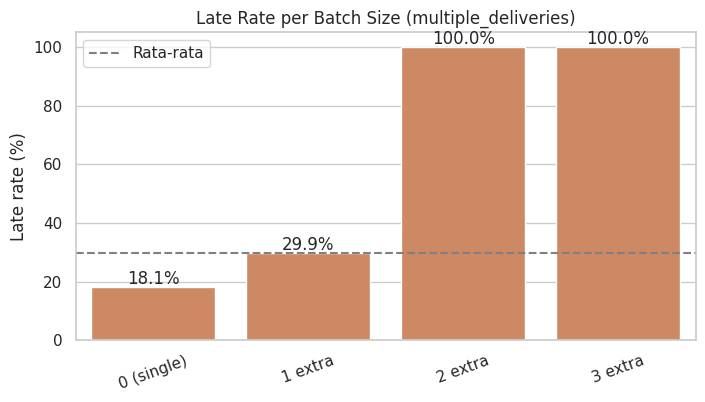

,orders,avg_time,late_rate_%
batch_size,,,
0 (single),14056,22.875,18.1
1 extra,29094,26.718,29.9
2 extra,1982,40.457,100.0
3 extra,361,47.820,100.0


In [61]:
plot_late("batch_size", "Late Rate per Batch Size (multiple_deliveries)")

Kalau kurir hanya mengantar 1 pesanan, keterlambatan 18,1%. Tapi begitu kurir membawa 2 pesanan tambahan atau lebih, 100% pesanan terlambat. Ini menunjukkan bahwa membawa banyak pesanan sekaligus sangat memperlambat pengiriman.

#### Late rate per festival dan kota

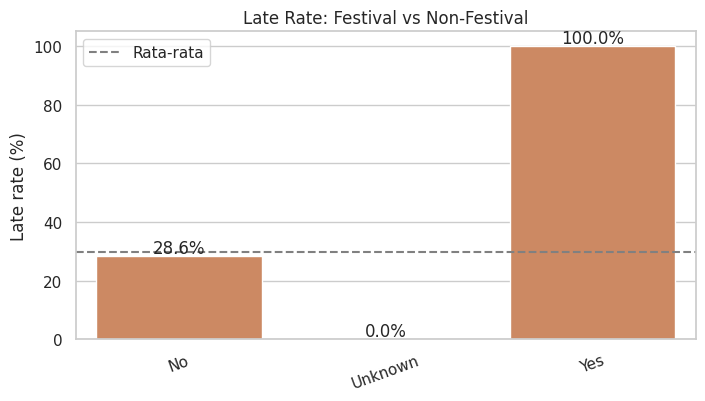

,orders,avg_time,late_rate_%
Festival,,,
No,44371,25.987,28.6
Unknown,228,11.167,0.0
Yes,894,45.517,100.0


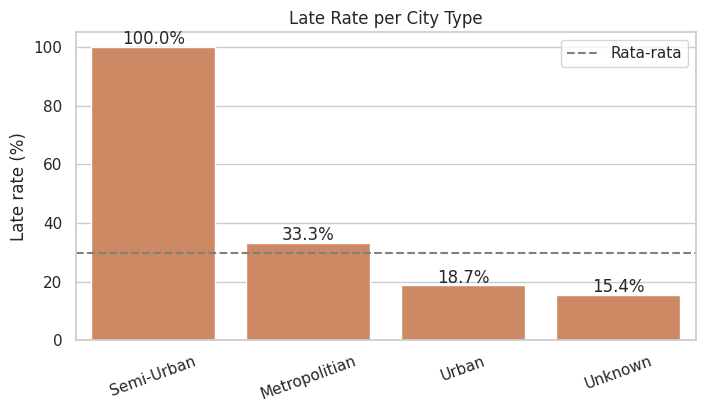

,orders,avg_time,late_rate_%
City,,,
Semi-Urban,164,49.732,100.0
Metropolitian,34023,27.317,33.3
Urban,10108,22.986,18.7
Unknown,1198,22.067,15.4


In [62]:
display(plot_late("Festival", "Late Rate: Festival vs Non-Festival"))
display(plot_late("City", "Late Rate per City Type", urut=True))

Saat festival, 100% pesanan terlambat (894 pesanan), dengan rata-rata waktu 45,5 menit. Festival bisa diprediksi dari kalender, jadi masalahnya bukan lonjakan yang tak terduga, melainkan kapasitas yang belum disiapkan. Kota Semi-Urban juga 100% terlambat, tetapi hanya 164 pesanan (0,4%). Pesanan Semi-Urban rata-rata berjarak 12,9 km (rata-rata keseluruhan 9,7 km), 82% terjadi saat macet, dan 25% di hari festival, jadi angka 100% ini kemungkinan gabungan beberapa faktor risiko. Kota Urban hanya 18,7%.

#### Late rate per kondisi kendaraan dan jenis kendaraan

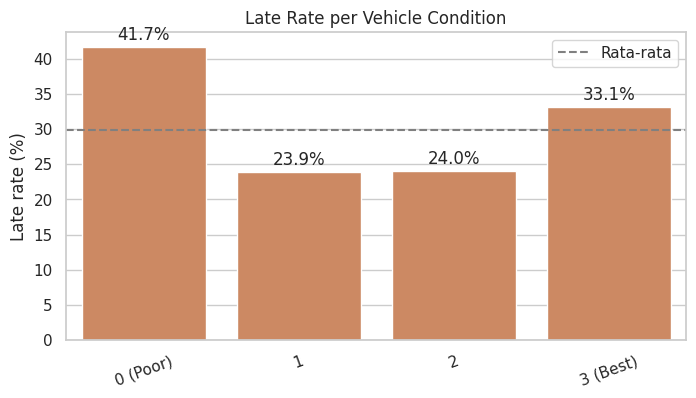

,orders,avg_time,late_rate_%
vehicle_condition_label,,,
0 (Poor),15005,30.073,41.7
1,15028,24.354,23.9
2,15031,24.454,24.0
3 (Best),429,26.851,33.1


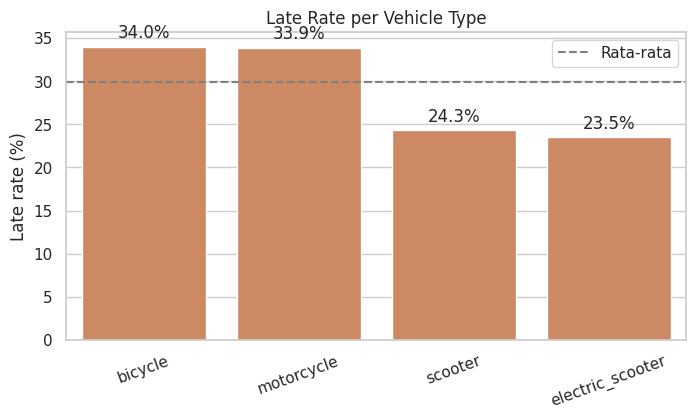

,orders,avg_time,late_rate_%
Type_of_vehicle,,,
bicycle,53,26.717,34.0
motorcycle,26421,27.606,33.9
scooter,15241,24.477,24.3
electric_scooter,3778,24.477,23.5


In [63]:
display(plot_late("vehicle_condition_label", "Late Rate per Vehicle Condition"))
display(plot_late("Type_of_vehicle", "Late Rate per Vehicle Type", urut=True))

Kendaraan kondisi 0 (paling buruk) memiliki late rate 41,7%, sedangkan kondisi 1 dan 2 sekitar 24%. Kondisi 3 justru 33,1%, tetapi jumlahnya hanya 429 pesanan. Motor terlihat lebih lambat (33,9%) dibanding skuter (24,3%), tetapi itu karena kondisi 0 hanya ada pada motor. Jadi yang berpengaruh adalah kondisi kendaraan, bukan jenisnya. Sepeda hanya 53 pesanan, terlalu sedikit untuk disimpulkan.

#### Late rate per jenis pesanan

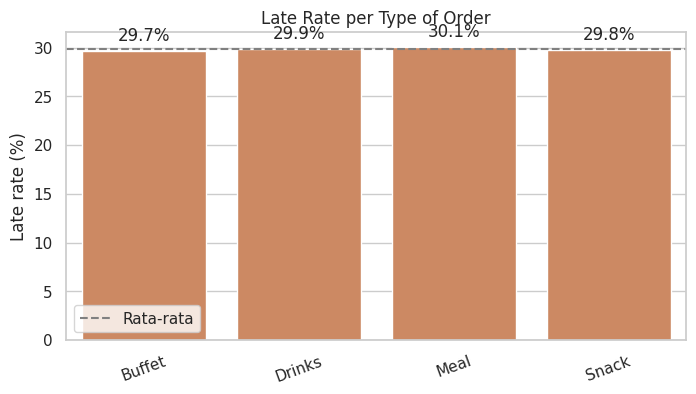

,orders,avg_time,late_rate_%
Type_of_order,,,
Buffet,11258,26.279,29.7
Drinks,11293,26.195,29.9
Meal,11433,26.426,30.1
Snack,11509,26.286,29.8


In [64]:
plot_late("Type_of_order", "Late Rate per Type of Order")

Semua jenis pesanan (Meal, Snack, Drinks, Buffet) memiliki tingkat keterlambatan yang hampir sama, sekitar 29,7% sampai 30,1%. Artinya jenis pesanan tidak berpengaruh terhadap keterlambatan.

#### Late rate per jarak

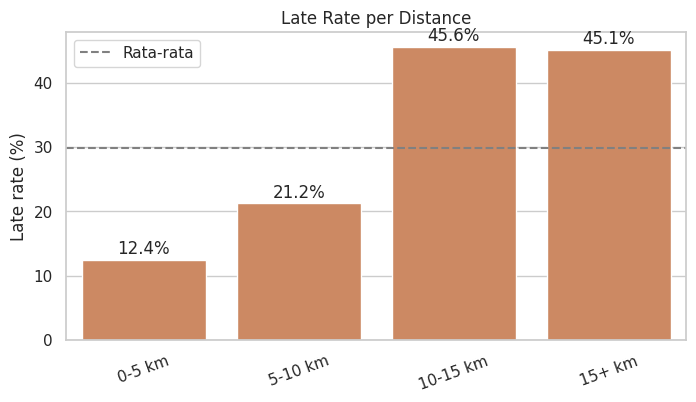

,orders,avg_time,late_rate_%
distance_group,,,
0-5 km,11279,22.190,12.4
5-10 km,11286,24.387,21.2
10-15 km,11270,29.845,45.6
15+ km,8028,29.866,45.1


In [65]:
plot_late("distance_group", "Late Rate per Distance")

Semakin jauh jaraknya, semakin tinggi keterlambatan. Jarak 0 sampai 5 km hanya 12,4% terlambat, tapi jarak 10 sampai 15 km sudah 45,6% terlambat. Jadi jarak adalah faktor yang cukup besar pengaruhnya.

#### Late rate per profil kurir

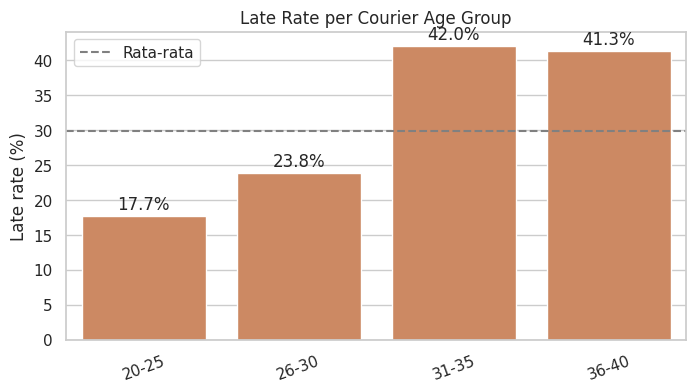

,orders,avg_time,late_rate_%
age_group,,,
20-25,12953,22.967,17.7
26-30,12759,24.594,23.8
31-35,10933,29.650,42.0
36-40,8848,29.483,41.3


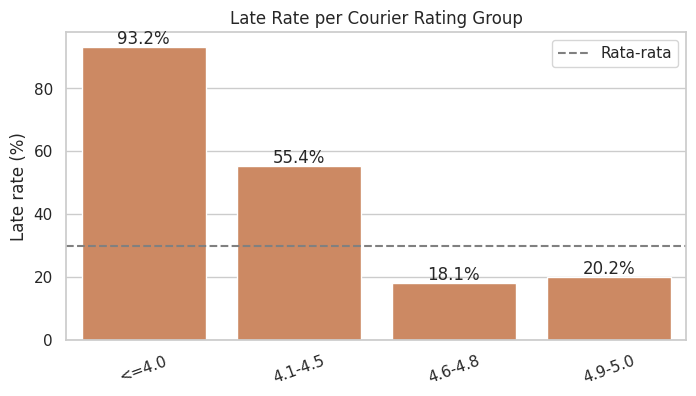

,orders,avg_time,late_rate_%
rating_group,,,
<=4.0,2406,36.069,93.2
4.1-4.5,8919,30.563,55.4
4.6-4.8,23132,24.430,18.1
4.9-5.0,11036,24.633,20.2


In [66]:
display(plot_late("age_group", "Late Rate per Courier Age Group"))
display(plot_late("rating_group", "Late Rate per Courier Rating Group"))

Kurir yang lebih muda (20 sampai 25 tahun) memiliki tingkat keterlambatan lebih rendah (17,7%) dibanding kurir yang lebih tua (36 sampai 40 tahun, 41,3%). Tapi hati-hati, rating kurir yang rendah (≤4.0) punya keterlambatan 93,2%, ini bisa jadi karena kurir yang sering terlambat mendapat rating rendah, bukan sebaliknya.

#### Tren harian late rate

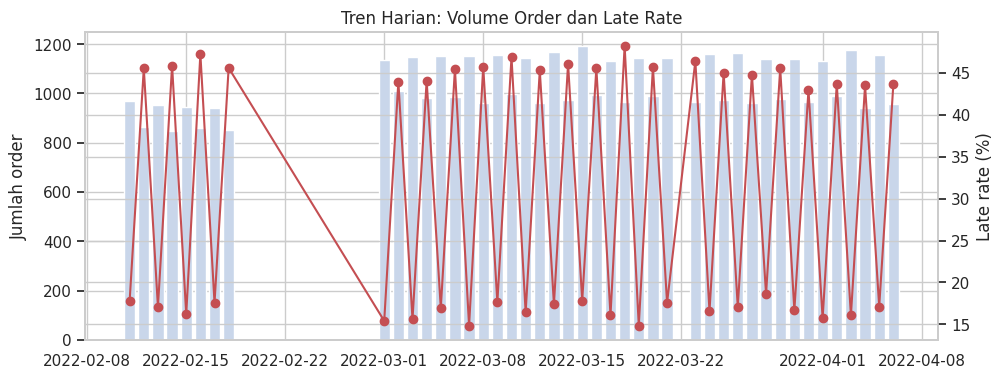

In [67]:
harian = df.groupby("Order_Date").agg(orders=("ID", "count"), late_rate=("is_late", "mean")).reset_index()
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(harian["Order_Date"], harian["orders"], color="#C9D6EA", label="Orders")
ax1.set_ylabel("Jumlah order")
ax2 = ax1.twinx()
ax2.plot(harian["Order_Date"], harian["late_rate"] * 100, color="#C44E52", marker="o", label="Late rate %")
ax2.set_ylabel("Late rate (%)")
ax1.set_title("Tren Harian: Volume Order dan Late Rate")
plt.show()

Late rate per hari naik turun tajam antara 14,8% dan 48,2%, dengan pola selang-seling: tanggal genap rata-rata 39,1% terlambat, tanggal ganjil 22,1%. Pola serapi ini kemungkinan besar artefak data sintetis, bukan perilaku operasional nyata. Per bulan, late rate relatif stabil (Februari 30,9%, Maret 29,9%, April 28,7%). Data tanggal 19 sampai 28 Februari dan 22 Maret tidak tersedia.

#### Pola per jam order

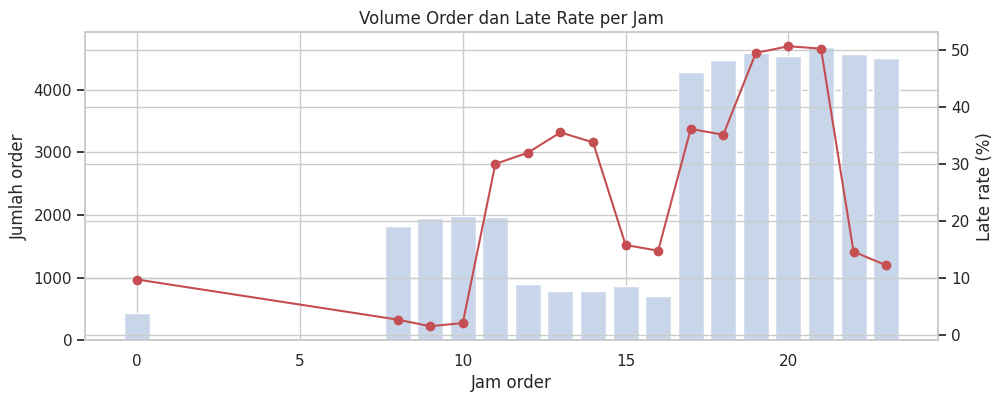

,orders,avg_time,late_rate_%
time_slot,,,
1 Morning (06-11),5755,19.534,2.2
2 Lunch (11-15),4427,26.882,32.0
3 Afternoon (15-17),1582,23.082,15.4
4 Early Evening (17-19),8756,27.339,35.6
5 Dinner Peak (19-22),13816,31.033,50.0
6 Late Night (22-06),9517,22.796,13.3
Unknown,1640,26.398,30.8


In [68]:
per_jam = df.dropna(subset=["order_hour"]).groupby("order_hour").agg(
    orders=("ID", "count"), late_rate=("is_late", "mean")).reset_index()
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(per_jam["order_hour"], per_jam["orders"], color="#C9D6EA")
ax1.set_ylabel("Jumlah order")
ax1.set_xlabel("Jam order")
ax2 = ax1.twinx()
ax2.plot(per_jam["order_hour"], per_jam["late_rate"] * 100, color="#C44E52", marker="o")
ax2.set_ylabel("Late rate (%)")
ax1.set_title("Volume Order dan Late Rate per Jam")
plt.show()
late_rate("time_slot")

Pada jam makan malam (19.00 sampai 22.00), late rate mencapai 50%, tertinggi di antara semua slot. Slot ini hanya 30,4% dari pesanan, tetapi menyumbang 50,9% dari seluruh keterlambatan. Pagi hari (06.00 sampai 11.00) hanya 2,2%. Jadi jam makan malam adalah titik paling berisiko.

#### Risk matrix traffic x cuaca

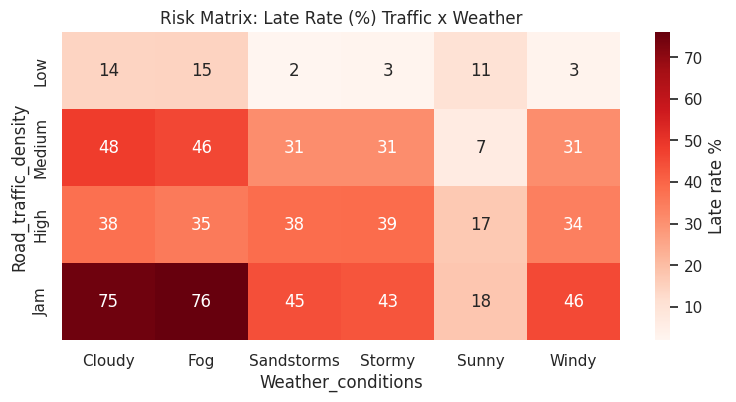

In [69]:
pivot = pd.pivot_table(df[(df["Road_traffic_density"] != "Unknown") & (df["Weather_conditions"] != "Unknown")],
                       values="is_late", index="Road_traffic_density", columns="Weather_conditions",
                       aggfunc="mean").reindex(["Low", "Medium", "High", "Jam"]) * 100
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Reds", ax=ax, cbar_kws={"label": "Late rate %"})
ax.set_title("Risk Matrix: Late Rate (%) Traffic x Weather")
plt.show()

Kombinasi paling berisiko adalah lalu lintas macet (Jam) dengan cuaca berkabut (76%) atau mendung (75%). Kombinasi ini mencakup 10,5% pesanan, tetapi menyumbang 26,5% dari seluruh keterlambatan. Kombinasi paling aman adalah lalu lintas lancar dengan cuaca Sandstorms atau Stormy (2 sampai 3%). Lalu lintas lancar dengan cuaca cerah justru 11%.

#### Risk matrix traffic x batch size

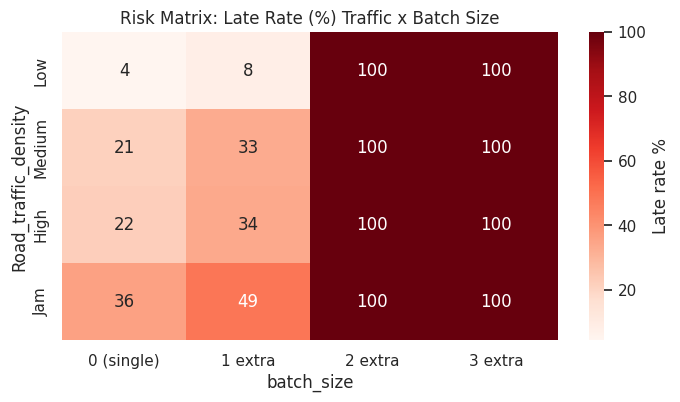

In [70]:
pivot2 = pd.pivot_table(df[df["Road_traffic_density"] != "Unknown"], values="is_late",
                        index="Road_traffic_density", columns="batch_size",
                        aggfunc="mean").reindex(["Low", "Medium", "High", "Jam"]) * 100
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="Reds", ax=ax, cbar_kws={"label": "Late rate %"})
ax.set_title("Risk Matrix: Late Rate (%) Traffic x Batch Size")
plt.show()

Saat kurir membawa 2 atau 3 pesanan tambahan, 100% pesanan terlambat di semua kondisi lalu lintas, bahkan saat lancar. Sebaliknya, batching 1 pesanan tambahan masih relatif aman saat lalu lintas lancar (8%), tetapi berisiko saat macet (49%). Jadi batch size adalah faktor terkuat yang bisa dikendalikan perusahaan.

#### Korelasi variabel numerik

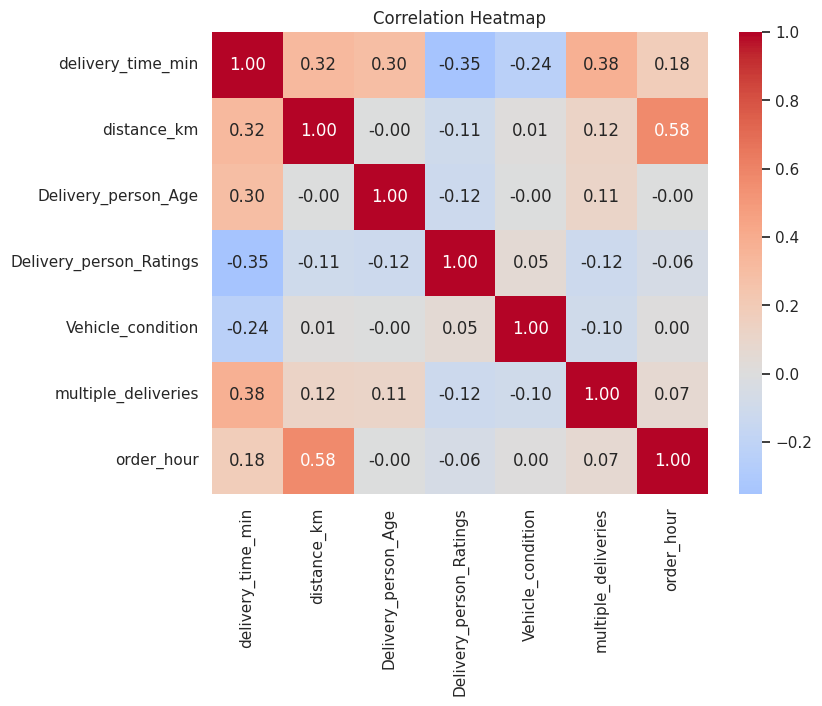

In [71]:
num_cols = ["delivery_time_min", "distance_km", "Delivery_person_Age", "Delivery_person_Ratings",
            "Vehicle_condition", "multiple_deliveries", "order_hour"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

Waktu pengiriman paling berkorelasi dengan multiple_deliveries (0,38), rating kurir (-0,35), jarak (0,32), dan umur kurir (0,30). Semua korelasi ini lemah sampai sedang, jadi tidak ada satu faktor tunggal yang dominan. Kondisi kendaraan berkorelasi negatif (-0,24): makin baik kondisinya, makin cepat pengiriman. Jarak juga berkorelasi 0,58 dengan jam order, artinya pesanan malam cenderung lebih jauh, sehingga efek jarak dan efek jam saling tumpang tindih.

#### Scatter jarak vs waktu

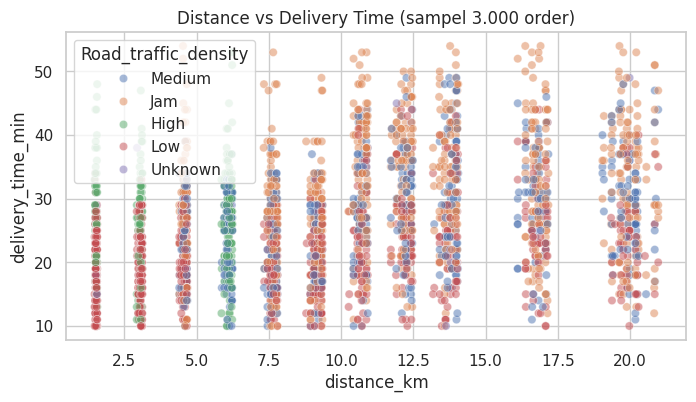

In [72]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df.sample(3000, random_state=42), x="distance_km", y="delivery_time_min",
                hue="Road_traffic_density", alpha=0.5, ax=ax)
ax.set_title("Distance vs Delivery Time (sampel 3.000 order)")
plt.show()

## 5. Ringkasan Faktor

#### Ringkasan faktor (ranking berdasarkan selisih late rate)

In [73]:
faktor = {
    "Festival": ("Festival", "Tidak (antisipasi)"),
    "Batch size": ("batch_size", "Ya"),
    "City type": ("City", "Tidak (antisipasi)"),
    "Traffic": ("Road_traffic_density", "Tidak (antisipasi)"),
    "Weather": ("Weather_conditions", "Tidak (antisipasi)"),
    "Time slot": ("time_slot", "Sebagian (alokasi kurir)"),
    "Distance": ("distance_group", "Sebagian (radius layanan)"),
    "Courier age": ("age_group", "Sebagian (penugasan)"),
    "Vehicle condition": ("vehicle_condition_label", "Ya"),
    "Vehicle type": ("Type_of_vehicle", "Ya"),
    "Type of order": ("Type_of_order", "Tidak relevan"),
}
baris = []
for nama, (kolom, kontrol) in faktor.items():
    t = late_rate(kolom)
    t = t[t.index.astype(str) != "Unknown"]
    baris.append({"factor": nama, "controllable": kontrol,
                  "lowest_late_%": t["late_rate_%"].min(), "highest_late_%": t["late_rate_%"].max(),
                  "gap_pp": round(t["late_rate_%"].max() - t["late_rate_%"].min(), 1)})
ringkasan = pd.DataFrame(baris).sort_values("gap_pp", ascending=False).reset_index(drop=True)
ringkasan

,factor,controllable,lowest_late_%,highest_late_%,gap_pp
0,Batch size,Ya,18.1,100.0,81.9
1,City type,Tidak (antisipasi),18.7,100.0,81.3
2,Festival,Tidak (antisipasi),28.6,100.0,71.4
3,Time slot,Sebagian (alokasi kurir),2.2,50.0,47.8
4,Traffic,Tidak (antisipasi),7.9,50.6,42.7
5,Distance,Sebagian (radius layanan),12.4,45.6,33.2
6,Weather,Tidak (antisipasi),12.5,43.8,31.3
7,Courier age,Sebagian (penugasan),17.7,42.0,24.3
8,Vehicle condition,Ya,23.9,41.7,17.8
9,Vehicle type,Ya,23.5,34.0,10.5


Tiga faktor dengan perbedaan keterlambatan terbesar adalah: batch size (81,9 poin), tipe kota (81,3 poin), dan festival (71,4 poin). Dari ketiganya, batch size adalah satu-satunya yang bisa dikendalikan perusahaan, yaitu dengan membatasi jumlah pesanan per kurir. Tipe kota dan festival hanya bisa diantisipasi dengan persiapan ekstra.

## 6. Export Data untuk Power BI

#### Export data bersih untuk Power BI

In [74]:
kolom_export = ["ID", "Delivery_person_ID", "Order_Date", "day_name", "order_hour", "time_slot",
                "Delivery_person_Age", "age_group", "Delivery_person_Ratings", "rating_group",
                "Weather_conditions", "Road_traffic_density", "Vehicle_condition", "vehicle_condition_label",
                "Type_of_order", "Type_of_vehicle", "multiple_deliveries", "batch_size", "Festival", "City",
                "distance_km", "distance_group", "pickup_wait_min", "delivery_time_min", "is_late", "delivery_status"]
df[kolom_export].to_csv("zomato_clean.csv", index=False)
print("Tersimpan:", len(df), "baris")

Tersimpan: 45493 baris
